## Exercise 9
Viene implementato un *Algoritmo Genetico* (AG) applicato al *Travelling Salesman Problem* (TSP), cioè la ricerca del percorso più breve che visiti una sola volta un insieme di $34$ città (ritornando al punto di partenza), distribuite lungo una circonferenza e all’interno di un quadrato.

Si genera una popolazione iniziale di $100$ percorsi casuali, alla quale vengono applicate perturbazioni (mutazioni, mantenendo fissa la città $1$). La popolazione viene poi ordinata in base al costo totale del percorso $L$ in ordine crescente. Da questa popolazione vengono selezionati $2$ percorsi favorevoli che, combinati tramite crossover, generano $2$ nuovi percorsi (con probabilità del $60$%, altrimenti vengono mantenuti invariati), introducendo così diversità genetica.

Questo procedimento viene ripetuto per $600$ generazioni, salvando il miglior percorso e la media della migliore metà della popolazione. Si ottengono le seguenti grafiche:
<p style="display: flex; justify-content: space-between;">
    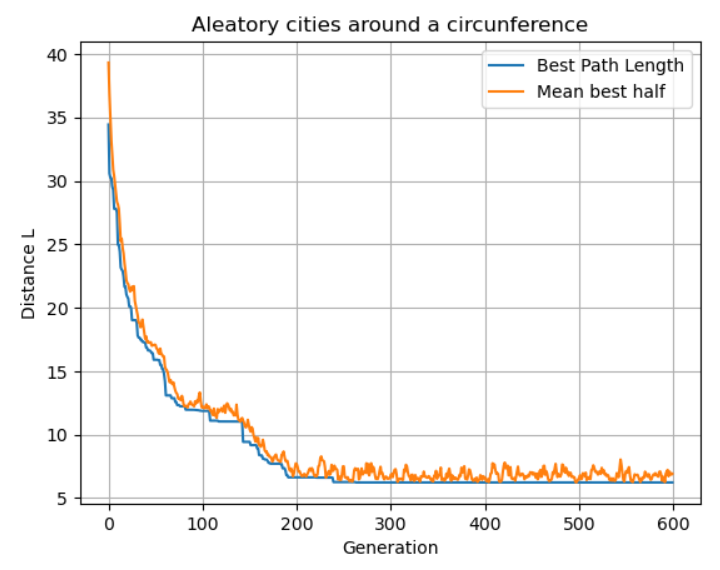
    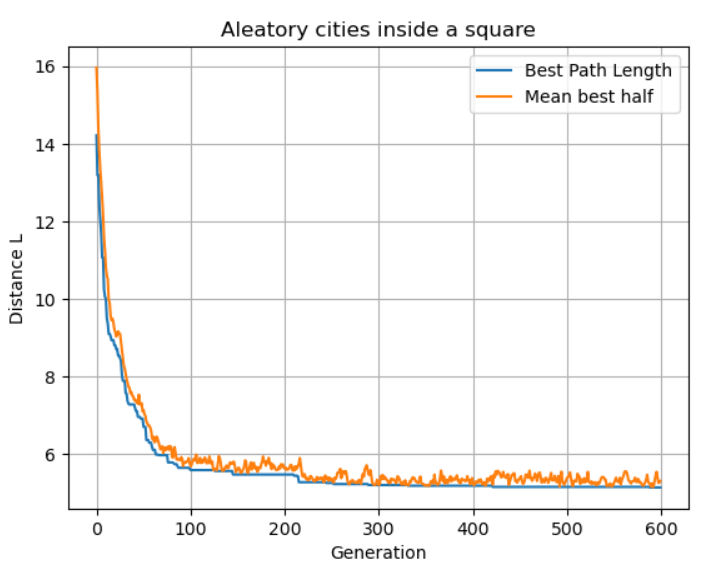
</p>

I risultati mostrano l’efficacia del processo: la distanza del percorso diminuisce rapidamente nelle prime generazioni, indicando che l’algoritmo scarta velocemente le soluzioni meno efficienti, e poi si stabilizza verso un valore minimo quasi costante. Le piccole fluttuazioni residue nella media indicano la diversità introdotta dalle mutazioni, che consente di esplorare nuove regioni dello spazio delle soluzioni.
<p style="display: flex; justify-content: space-between;">
    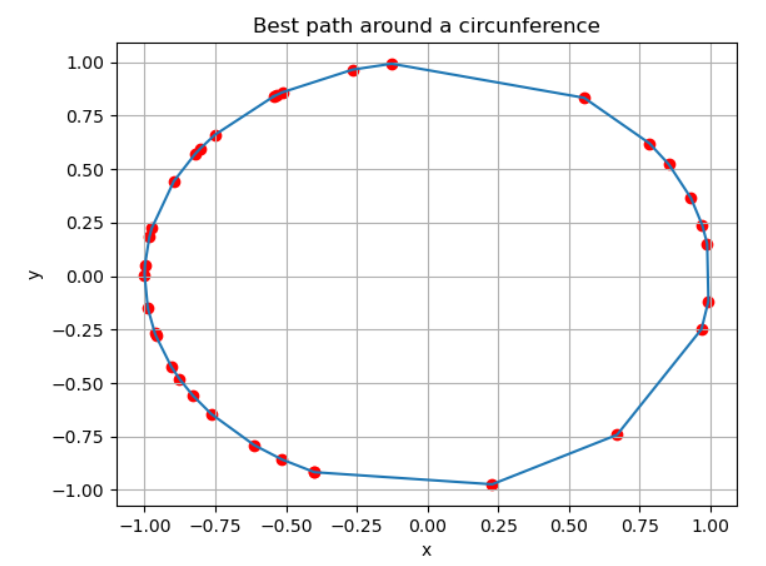
    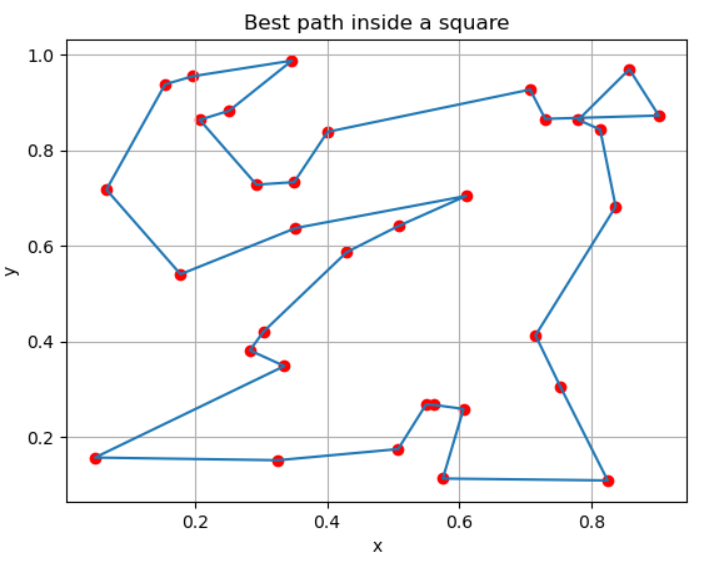
</p>

Le due ultime figure mostrano i percorsi ottimali trovati: nel caso della distribuzione su circonferenza, la soluzione corrisponde essenzialmente al perimetro della circonferenza senza incroci; nel caso del quadrato, il percorso ottimale collega tutti i punti con un numero minimo di intersezioni. In entrambi i casi si verifica che il metodo è efficace nel minimizzare il problema proposto.



In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

"""Cost function: total length"""
def L(vect, c):
    d = 0
    for i in range(len(vect) - 1):
        d += math.sqrt((c[vect[i+1]][0] - c[vect[i]][0])**2+
                      (c[vect[i+1]][1] - c[vect[i]][1])**2)      # |c(i+1) - c(i)|^2
    d += math.sqrt((c[vect[-1]][0] - c[vect[0]][0])**2 +
                   (c[vect[-1]][1] - c[vect[0]][1])**2)         # Traveler returns home
    return d

"""Verification function"""
def check(vect, N):
    return (len(vect)==len(np.unique(vect))==N) and (vect[0]==0)

"""Creation of the initial population"""
def initial_pob(N, M):
    p = np.zeros((M, N), dtype=int)
    p1 = np.arange(N)
    for i in range(M):
        v_i = p1.copy() 
        np.random.shuffle(v_i[1:])
        p[i] = v_i
    return p

"""Compute Fitness, path length"""
def Fitness(pob, c):
    fit = np.zeros(len(pob))
    for m in range(len(pob)):
        fit[m] = L(pob[m], c)
    return fit

"""Selection favoring better cities"""
def selection(M, p):
    r = np.random.rand()
    return int(M*(r**p))

# Mutation operators
"""Swap two cities"""
def mut_change(rute):
    pos1, pos2 = np.random.choice(range(1, len(rute)), 2, replace=False)
    rute[pos1], rute[pos2] = rute[pos2], rute[pos1]       # Change the routes
    return rute
"""Inverse a secuence of cities""" 
def mut_inv(rute):
    pos1, pos2 = sorted(np.random.choice(range(1, len(rute)), 2, replace=False))
    rute[pos1:pos2] = rute[pos1:pos2][::-1]               # Invert the order
    return rute
"""Shift a block of cities"""
def mut_shift(rute):
    N = len(rute)
    m = np.random.randint(1, N-2)                    # Length of the block
    pos1 = np.random.randint(1, N-m)               # Starting position of the move
    shift = np.random.randint(1, N-pos1-m+1)
    block = rute[pos1:pos1 + m].copy()
    rute[pos1:pos1 + shift] = rute[pos1+m:pos1+m+shift]
    rute[pos1+shift:pos1+m+shift] = block
    return rute
"""Swap two blocks of cities"""
def mut_blocks(rute):
    N = len(rute)
    m = np.random.randint(1, N//2)                  # Length of the block
    pos1 = np.random.randint(1, N-2*m+1)            
    pos2 = np.random.randint(pos1+m, N-m+1)
    block = rute[pos1:pos1+m].copy()
    rute[pos1:pos1+m] = rute[pos2:pos2+m]
    rute[pos2:pos2+m] = block
    return rute
"""Apply all the mutations with a 0.1 probability each"""
def mutations(rute):
    if np.random.rand() < 0.1:
        mut_shift(rute)
    if np.random.rand() < 0.1:
        mut_inv(rute)
    if np.random.rand() < 0.1:
        mut_change(rute)
    if np.random.rand() < 0.1:
        mut_blocks(rute)
    return rute

"""Crossover between two individuals"""
def crossover(mom, dad):
    N = len(mom)
    son1 = np.zeros(N, dtype=int)
    son2 = np.zeros(N, dtype=int)
    cut = np.random.randint(1, N)
    son1[:cut] = mom[:cut]
    son2[:cut] = dad[:cut]
    k = cut
    for c in dad:
        if c not in son1[:cut]:
            son1[k] = c
            k += 1
    k = cut
    for c in mom:
        if c not in son2[:cut]:
            son2[k] = c
            k += 1
    return son1, son2

"""Creates a new generation"""
def new_generation(pob,c):
    M = len(pob)
    new_pob = []
    while len(new_pob) < M:       # repeat till fill the poblation
        mother = pob[selection(M, 2)].copy()
        father = pob[selection(M, 2)].copy()
        if np.random.rand() < 0.6:
            son1, son2 = crossover(mother, father)
        else:
            son1, son2 = mother, father
        son1 = mutations(son1)
        son2 = mutations(son2)
        # Verify if the sons meet the requirements
        if not check(son1, N) or not check(son2, N):
            raise ValueError("Incorrected values for the sons creation")
        new_pob.append(son1)
        if len(new_pob) < M:
            new_pob.append(son2)
    return np.array(new_pob)
    
"""GENETIC ALGORITHM"""
def AG(c, M, N, GEN, title):
    pob = initial_pob(N, M)           # Poblation: M vectors of length N
    best_rute = np.zeros(GEN)           # Traveler rute
    best_mean = np.zeros(GEN)           # Traveler rute

    for g in range(GEN):
        fit = Fitness(pob, c)             # Fitness
        # Re-ordenate from worst to best
        index = np.argsort(fit)
        fit = fit[index]
        pob = pob[index]
        
        best_rute[g] = fit[0]
        best_mean[g] = np.mean(np.sort(fit)[:len(fit)//2])
        if g < GEN -1:
            pob = new_generation(pob, c)
        
    # Evolution plot
    plt.figure()
    plt.plot(best_rute, label="Best Path Length")
    plt.plot(best_mean, label="Mean best half")
    plt.xlabel('Generation')
    plt.ylabel('Distance L')
    plt.title(f'Aleatory cities {title}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Path plot
    best_rute_index = pob[0]
    final_rute = np.append(best_rute_index, best_rute_index[0]) # Ends at the start
    plt.figure()
    plt.plot(c[final_rute, 0], c[final_rute, 1])
    plt.scatter(c[:,0], c[:,1], color='red')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Best path {title}')
    plt.grid(True)
    plt.show()
    
# FINAL ALGORITHM    
N = 34                            # Number of cities
M = 100                           # Poblation length
GEN = 600                         # Generation

# For cities around a cincunference
c_circle = np.zeros((N, 2))       # Positions of each city 
for i in range(N):
    theta = 2*math.pi*np.random.rand()
    c_circle[i] = (math.cos(theta), math.sin(theta))
AG(c_circle, M, N, GEN, "around a circunference")

# For cities inside a square
c_square = np.random.rand(N, 2)   # Positions of each city
AG(c_square, M, N, GEN, "inside a square")
